# Learning to Implement Normalizing Flows

## TO-DO:  
- make own implementation of CosineLR scheduler
- make comparison of best model configurations like for Diffusion

In [ ]:
import matplotlib
import math
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import torch
import torch.distributions as td
from torch.distributions.mixture_same_family import MixtureSameFamily
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.utils import save_image
from tqdm import tqdm
from typing import Tuple

import sys
sys.path.append("/home/alzub/projects/ggdl_self_learn/code/")
from plot_utils import set_plot_style
from nn_.mlp import MLP
from nn_.cnn import Conv2DLayer
from nn_.transformer import CausalSDPA
from generative.conditioning import FILMedCNN
from generative.base_dists import GaussianBase
from generative.norm_flows import (
    checkerboard_mask_1d, checkerboard_mask_2d, channel_mask,
    PermutationIdentity, PermutationFlip,
    ActNorm1d, ActNorm2d, NormalizingFlow, NFPatchified, RealNVPBlock,
    TarFlowBlock
)
from generative.utils import tweedie_denoise

In [ ]:
set_plot_style()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROJECT_DIR = Path("/home/alzub/projects/ggdl_self_learn")
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = DATA_DIR / "models/normalizing_flows"
SAMPLE_DIR = DATA_DIR / "samples/normalizing_flows"

plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128
plt.ioff()

NF_NAME_MAP = {
    "realnvp": "RealNVP", "tarflow": "TarFlow"
}

# 0. Prerequisites

## 0.1 Data

### 0.1.1 Toy Distributions

In [3]:
class TwoGaussians:
    def __init__(self):
        """
        A simple class to define an uneven mixture of two Gaussians.
        """

        mixture = td.Categorical(torch.tensor([1/5, 4/5]))
        components = td.Independent(td.Normal(
            torch.Tensor([
                [0.75, 0.75],
                [0.25, 0.25]
            ]),
            torch.Tensor([
                [0.1, 0.1],
                [0.1, 0.1]
            ])
        ), 1)
        self.distribution = MixtureSameFamily(mixture, components)

        self.xlim = (0, 1)
        self.ylim = (0, 1)

    def __call__(self):
        """
        Return the distribution.
        Returns:
        distribution: [torch.distributions.Distribution]
        """
        return self.distribution


class ExtendedUniform(td.Uniform):
    def __init__(self, low, high, validate_args=None, outside_value=-float('inf')):
        """
        A uniform distribution that returns a constant value for values outside the support
        """
        super(ExtendedUniform, self).__init__(low, high, validate_args)
        self.outside_value = outside_value

    def log_prob(self, value):
        # Check if the value is within the support
        in_support = (value >= self.low) & (value <= self.high)
        safe_value = torch.where(in_support, value, self.low)
        log_prob = super().log_prob(safe_value)
        
        # Set log_prob to self.outside_value for values outside the support
        log_prob = torch.where(in_support, log_prob, torch.full_like(log_prob, self.outside_value))
        return log_prob
    
    @td.constraints.dependent_property(is_discrete=False, event_dim=0)
    def support(self):
        return td.constraints.real

class Chequerboard:
    def __init__(self, grid_size=3, bounds=[0.0, 1.0]):
        """
        A simple class to define the Chequerboard distribution.
        """

        square_size = (bounds[1] - bounds[0]) / grid_size

        weights = []
        low_list = []
        high_list = []
        for i in range(grid_size):
            for j in range(grid_size):
                if (i + j) % 2 == 0:
                    low_x = bounds[0] + i * square_size
                    high_x = low_x + square_size
                    low_y = bounds[0] + j * square_size
                    high_y = low_y + square_size
                    
                    low_list.append([low_x, low_y])
                    high_list.append([high_x, high_y])
                    weights.append(1.0)

        mixture = td.Categorical(torch.tensor(weights))
        #components = td.Independent(td.uniform.Uniform(torch.tensor(low_list), torch.tensor(high_list)), 1)
        components = td.Independent(ExtendedUniform(torch.tensor(low_list), torch.tensor(high_list)), 1)
        self.distribution = MixtureSameFamily(mixture, components)

        self.xlim = bounds
        self.ylim = bounds

    def __call__(self):
        """
        Return the distribution.
        Returns:
        distribution: [torch.distributions.Distribution]
        """
        return self.distribution

### 0.1.2 MNIST

In [4]:
batch_size = 256

mnist_train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        PROJECT_DIR / "data", train=True, download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
    ),
    batch_size=batch_size, shuffle=True
)
mnist_test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        PROJECT_DIR / "data", train=False, download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
    ),
    batch_size=batch_size, shuffle=True
)

### 0.1.3 Pre- and Postprocessing Functions for RealNVP

In [5]:
def peprocess_realnvp(
    x: torch.Tensor, n_bins: int=256, alpha: float=1e-6
) -> Tuple[torch.Tensor, torch.Tensor]:
    assert x.dim() == 4
    B = x.size(0)

    x = (x + 1.0) * 0.5

    x = x * (n_bins - 1)
    x = (x + torch.rand_like(x)) / n_bins
    
    # soft clamping
    x = x * (1 - 2*alpha) + alpha
    x_tilde = torch.log(x) - torch.log1p(-x)
    log_det = (-torch.log(x) - torch.log1p(-x)).view(B, -1).sum(dim=1)

    return x_tilde, log_det

def postprocess_realnvp(x_tilde: torch.Tensor) -> torch.Tensor:
    x = torch.sigmoid(x_tilde)
    return x

## 0.2 Training Code

### 0.2.1 Optimizer Implementations

In [7]:
class CosineLRSchedule(torch.nn.Module):
    counter: torch.Tensor

    def __init__(self, optimizer, warmup_steps: int, total_steps: int, min_lr: float, max_lr: float):
        super().__init__()
        self.register_buffer('counter', torch.zeros(()))
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.optimizer = optimizer
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.set_lr(min_lr)

    def set_lr(self, lr: float) -> float:
        if self.min_lr <= lr <= self.max_lr:
            for pg in self.optimizer.param_groups:
                pg['lr'] = lr
        return max(self.min_lr, min(self.max_lr, lr))

    def step(self) -> float:
        with torch.no_grad():
            counter = self.counter.add_(1).item()
        if self.counter <= self.warmup_steps:
            new_lr = self.min_lr + counter / self.warmup_steps * (self.max_lr - self.min_lr)
            return self.set_lr(new_lr)

        t = (counter - self.warmup_steps) / (self.total_steps - self.warmup_steps)
        new_lr = self.min_lr + 0.5 * (1 + math.cos(math.pi * t)) * (self.max_lr - self.min_lr)
        return self.set_lr(new_lr)

# 1. Normalizing Flow Architectures

## 1.1 Wrappers/Blocks Specific for the Architectures Here

In [8]:
class CouplingMLP(MLP):
    def forward(self, x: torch.Tensor, **kwargs) -> torch.Tensor:
        x = self.network(x)
        return torch.chunk(x, 2, dim=1)

class ResidualAttentionBlock(nn.Module):
    def __init__(self, channels: int, head_channels: int, expansion: int=4):
        super().__init__()
        self.attention = CausalSDPA(channels, head_channels)
        self.mlp_norm = nn.LayerNorm(channels)
        self.mlp = MLP(
            channels, channels, [channels*expansion], act_funs=[nn.GELU, None])

    def forward(
        self, x: torch.Tensor, attn_mask: torch.Tensor|None=None,
        attn_temp: float=1.0, which_cache: str|None=None
    ) -> torch.Tensor:
        x = x + self.attention(
            x, attn_mask, attn_temp, which_cache=which_cache)
        x = x + self.mlp(self.mlp_norm(x.float()).type(x.dtype))
        return x

## 1.2 Functions Giving Architectures

In [9]:
def make_toy_realnvp(
    x_sample_size: int, hidden_size: int, n_total_trafos: int,
    n_block_trafos: int
) -> nn.Module:
    trafo_blocks = []
    for t in range(n_total_trafos):
        masks = []
        coupling_blocks = []
        act_norms = []
        for k in range(n_block_trafos):
            invert_flag = (k % 2 == 1)

            masks.append(checkerboard_mask_1d(
                x_sample_size, invert=invert_flag, device=DEVICE))
            coupling_blocks.append(CouplingMLP(
                x_sample_size, x_sample_size*2,
                [hidden_size]*(n_block_trafos-1),
                act_funs=[nn.GELU]*(n_block_trafos-1) + [None]
            ))
            act_norms.append(ActNorm1d(x_sample_size))


        trafo_blocks.append(RealNVPBlock(
            nn.ModuleList(coupling_blocks), nn.ModuleList(act_norms), masks,
            squeeze=False
        ))

    base_dist = GaussianBase((x_sample_size,))
    model = NormalizingFlow(
        base_dist, nn.ModuleList(trafo_blocks), device=DEVICE)
    
    return model

def make_toy_tarflow(
    x_sample_size: int, hidden_channel_size: int, head_channel_size: int,
    n_total_trafos: int, n_block_trafos: int, in_channel_size: int=1,
    expansion: int=4, 
) -> nn.Module:
    base_dist = GaussianBase((x_sample_size, 1))
    perms = [
        PermutationIdentity(x_sample_size), PermutationFlip(x_sample_size)]
    trafo_blocks = []
    for t in range(n_total_trafos):
        attn_blocks = []
        for k in range(n_block_trafos):
            attn_blocks.append(ResidualAttentionBlock(
                hidden_channel_size, head_channel_size, expansion=expansion))
        trafo_blocks.append(TarFlowBlock(
            perms[t % 2], nn.ModuleList(attn_blocks), in_channel_size,
            hidden_channel_size, x_sample_size
        ))
    model = NormalizingFlow(
        base_dist, nn.ModuleList(trafo_blocks), device=DEVICE)
    
    return model

# 2. NFs on Toy Data

## 2.1 TwoGaussians

In [26]:
# Generate the data
n_data = 10000000
toy = TwoGaussians()
train_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)

In [18]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

epochs = 3
lr = 2e-3

K = 6
T = 6
for nf_type, make_fun in zip(["realnvp", "tarflow"], [
    lambda x_s, t, k: make_toy_realnvp(x_s, 24, t, k),
    lambda x_s, t, k: make_toy_tarflow(x_s, 24, 8, t, k)
]):
    model = make_fun(x_sample_size, T, K).to(DEVICE)
    n_model_pars = sum(
        p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Number of {nf_type} Parameters: {n_model_pars}.")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = CosineLRSchedule(
        optimizer, len(train_loader), epochs * len(train_loader), 1e-6, lr)
    model.train()

    total_steps = len(train_loader)*epochs
    progress_bar = tqdm(range(total_steps), desc="Training")
    for epoch in range(epochs):
        for x in train_loader:
            optimizer.zero_grad()

            x = x.to(DEVICE)
            if nf_type == "tarflow":
                x = x.unsqueeze(-1)

            z, log_dets = model(x)
            loss = -(
                (model.base().log_prob(z) / z[0].numel()) + log_dets).mean()

            loss.backward()
            optimizer.step()
            scheduler.step()

            # Update progress bar
            progress_bar.set_postfix(
                loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
            progress_bar.update()

    torch.save(
        model.state_dict(),
        MODEL_DIR / f"toy1_{nf_type}_{epochs}_n_epochs_{K*T}_n_trafo.pt"
    )

Number of realnvp Parameters: 92736.


Training: 100%|██████████| 3000/3000 [06:35<00:00,  7.51it/s, epoch=3/3, loss=⠀     -2.8839]

Number of tarflow Parameters: 260940.


Training: 100%|██████████| 3000/3000 [06:36<00:00,  7.56it/s, epoch=3/3, loss=⠀     -2.8839]


In [19]:
progress_bar.reset()

/home/alzub/tmp/ipykernel_3676071/130825090.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


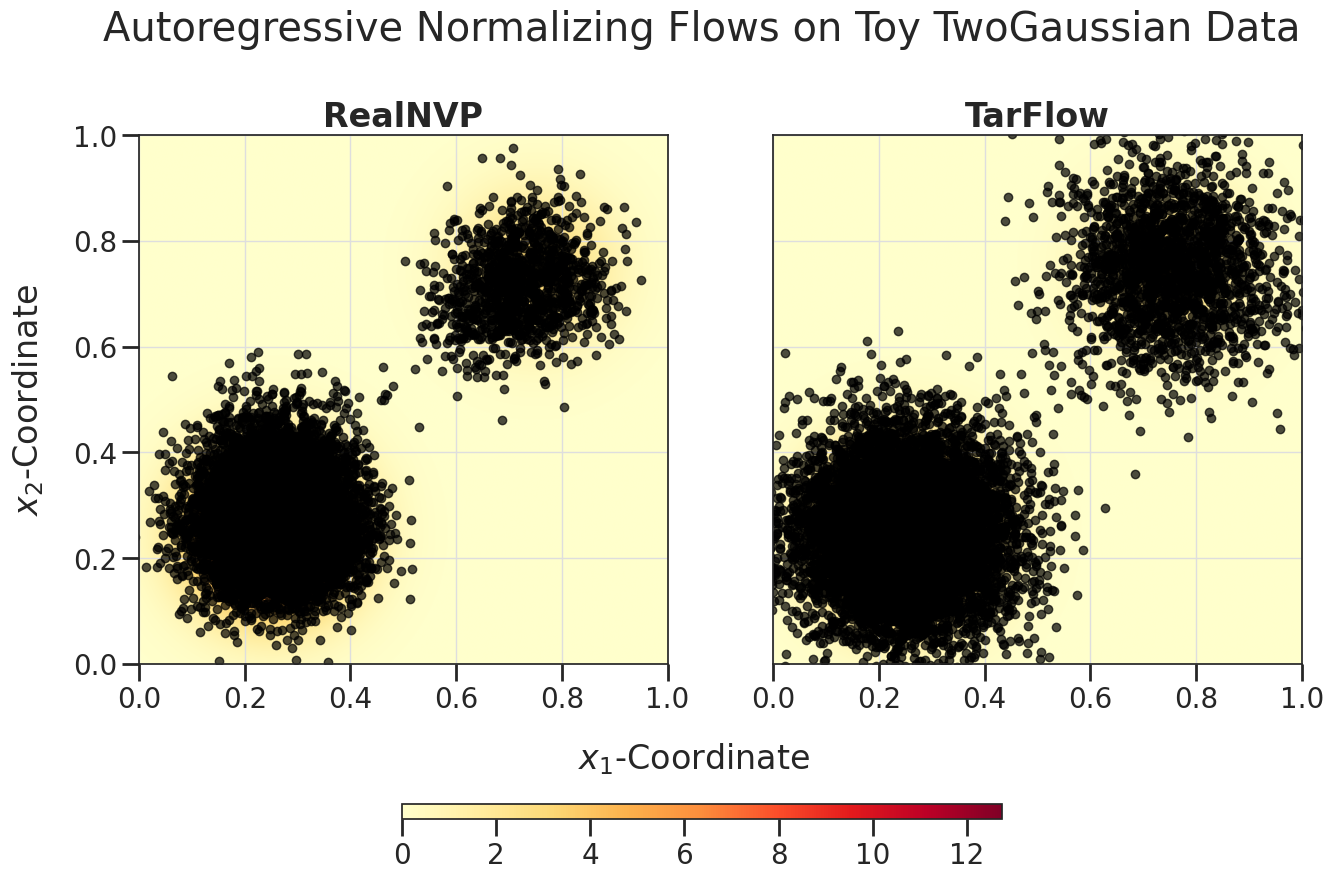

In [27]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig = plt.figure(figsize=(15, 15))
gs_plot = fig.add_gridspec(1, 2, bottom=0.1)
gs_cbar = fig.add_gridspec(1, 1, top=0.22, bottom=0.21, left=0.3, right=0.7)

epochs = 3
K = 6
T = 6
for i, (nf_type, make_fun) in enumerate(zip(["realnvp", "tarflow"], [
    lambda x_s, t, k: make_toy_realnvp(x_s, 24, t, k),
    lambda x_s, t, k: make_toy_tarflow(x_s, 24, 8, t, k)
])):
    model = make_fun(x_sample_size, T, K).to(DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"toy1_{nf_type}_{epochs}_n_epochs_{K*T}_n_trafo.pt",
        map_location=torch.device(DEVICE)
    ))
    with torch.no_grad():
        model.eval()
        samples = model.forward_flow((10000,))
        samples = samples.detach().cpu().numpy()

    ax = fig.add_subplot(gs_plot[i])
    im = ax.imshow(
        prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
        origin='lower', cmap='YlOrRd'
    )

    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.7, color="black")

    ax.set_xlim(toy.xlim)
    ax.set_ylim(toy.ylim)
    ax.set_aspect("equal")
        
    if i > 0:
        ax.tick_params(left=False, labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
    
    if i != 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("$x_1$-Coordinate", labelpad=20, x=-0.15)
    
    ax.set_title(NF_NAME_MAP[nf_type], weight="bold")
    
ax_cbar = fig.add_subplot(gs_cbar[0])
fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle(
    "Autoregressive Normalizing Flows on Toy TwoGaussian Data", y=0.75)

plt.show()

## 2.2 Chequerboard

In [22]:
# Generate the data
n_data = 10000000
toy = Chequerboard(bounds=[-2, 2])
train_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)

In [23]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

epochs = 3
lr = 2e-3

K = 6
T = 6
for nf_type, make_fun in zip(["realnvp", "tarflow"], [
    lambda x_s, t, k: make_toy_realnvp(x_s, 24, t, k),
    lambda x_s, t, k: make_toy_tarflow(x_s, 24, 8, t, k)
]):
    model = make_fun(x_sample_size, T, K).to(DEVICE)
    n_model_pars = sum(
        p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Number of {nf_type} Parameters: {n_model_pars}.")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = CosineLRSchedule(
        optimizer, len(train_loader), epochs * len(train_loader), 1e-6, lr)
    model.train()

    total_steps = len(train_loader)*epochs
    progress_bar = tqdm(range(total_steps), desc="Training")
    for epoch in range(epochs):
        for x in train_loader:
            optimizer.zero_grad()

            x = x.to(DEVICE)
            if nf_type == "tarflow":
                x = x.unsqueeze(-1)

            z, log_dets = model(x)
            loss = -(
                (model.base().log_prob(z) / z[0].numel()) + log_dets).mean()

            loss.backward()
            optimizer.step()
            scheduler.step()

            # Update progress bar
            progress_bar.set_postfix(
                loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
            progress_bar.update()

    torch.save(
        model.state_dict(),
        MODEL_DIR / f"toy2_{nf_type}_{epochs}_n_epochs_{K*T}_n_trafo.pt"
    )

Number of realnvp Parameters: 92736.


Training: 100%|██████████| 3000/3000 [06:17<00:00,  9.28it/s, epoch=3/3, loss=⠀      1.2263]

Number of tarflow Parameters: 260940.


Training: 100%|██████████| 3000/3000 [06:18<00:00,  7.93it/s, epoch=3/3, loss=⠀      1.2263]


In [24]:
progress_bar.reset()

/home/alzub/tmp/ipykernel_3676071/2126580203.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


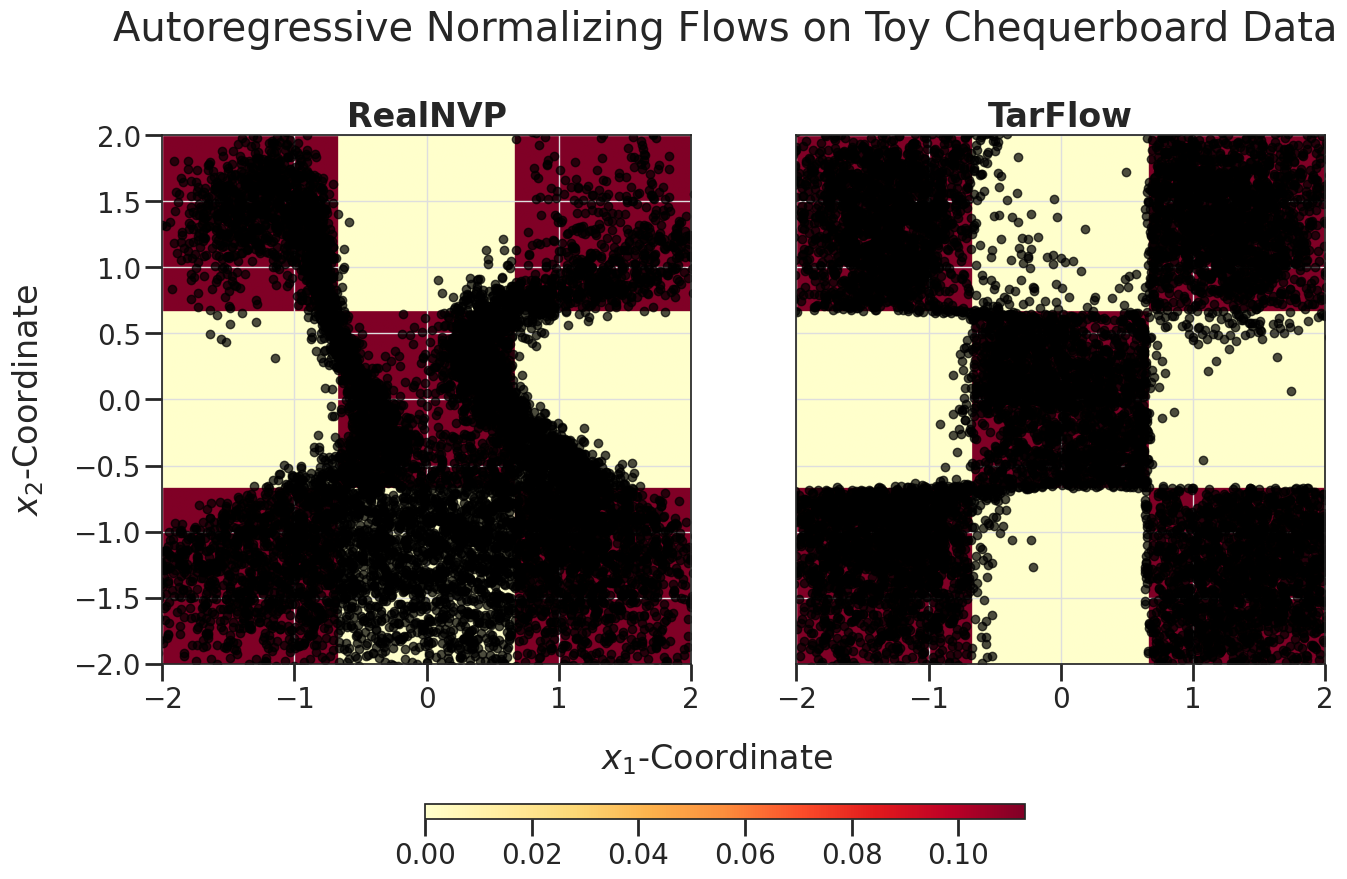

In [25]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig = plt.figure(figsize=(15, 15))
gs_plot = fig.add_gridspec(1, 2, bottom=0.1)
gs_cbar = fig.add_gridspec(1, 1, top=0.22, bottom=0.21, left=0.3, right=0.7)

epochs = 3
K = 6
T = 6
for i, (nf_type, make_fun) in enumerate(zip(["realnvp", "tarflow"], [
    lambda x_s, t, k: make_toy_realnvp(x_s, 24, t, k),
    lambda x_s, t, k: make_toy_tarflow(x_s, 24, 8, t, k)
])):
    model = make_fun(x_sample_size, T, K).to(DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"toy2_{nf_type}_{epochs}_n_epochs_{K*T}_n_trafo.pt",
        map_location=torch.device(DEVICE)
    ))
    with torch.no_grad():
        model.eval()
        samples = model.forward_flow((10000,))
        samples = samples.detach().cpu().numpy()

    ax = fig.add_subplot(gs_plot[i])
    im = ax.imshow(
        prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
        origin='lower', cmap='YlOrRd'
    )

    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.7, color="black")

    ax.set_xlim(toy.xlim)
    ax.set_ylim(toy.ylim)
    ax.set_aspect("equal")
        
    if i > 0:
        ax.tick_params(left=False, labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
    
    if i != 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("$x_1$-Coordinate", labelpad=20, x=-0.15)
    
    ax.set_title(NF_NAME_MAP[nf_type], weight="bold")
    
ax_cbar = fig.add_subplot(gs_cbar[0])
fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle(
    "Autoregressive Normalizing Flows on Toy Chequerboard Data", y=0.75)

plt.show()

# 3. NFs on Easy, Real Data

## 3.1 MNIST

### 3.1.1 RealNVP on MNIST

In [12]:
x_sample = next(iter(mnist_train_loader))[0][:1]
x_sample_size = x_sample.size()
data_size = x_sample_size[-1]

K = 4
T = 4
img_size = 28
in_channel_size = 1
hidden_channel_size = 128
cond_dim = 16
kernel_size = 3
padding = 1
n_classes = 10

trafo_blocks = []
new_hidden_size = in_channel_size
new_img_size = img_size
for t in range(T):
    masks = []
    coupling_blocks = []
    act_norms = []
    for k in range(K):
        invert_flag = (k % 2 == 1)
        if new_hidden_size == 1:
            masks.append(checkerboard_mask_2d(
                new_img_size, new_img_size, invert=invert_flag, device=DEVICE))
        else:
            masks.append(channel_mask(
                new_hidden_size, invert=invert_flag, device=DEVICE))
        
        coupling_blocks.append(FILMedCNN(
            Conv2DLayer(
                hidden_channel_size, hidden_channel_size, kernel_size, padding,
                pool=None, use_batchnorm=False, act_fun=None
            ), n_classes, cond_dim, new_hidden_size, hidden_channel_size,
            n_convs=4, act_fun=nn.GELU
        ))
        act_norms.append(ActNorm2d(new_hidden_size))
    
    if t % 2 == 0:
        new_hidden_size *= 4
        new_img_size //= 2
        squeeze = True
    else:
        squeeze = False
    trafo_blocks.append(RealNVPBlock(
        nn.ModuleList(coupling_blocks), nn.ModuleList(act_norms), masks,
        squeeze=squeeze
    ))

base_dist = GaussianBase((new_hidden_size, new_img_size, new_img_size))
model = NormalizingFlow(
    base_dist, nn.ModuleList(trafo_blocks), device=DEVICE).to(DEVICE)

In [ ]:
model.train()
lr = 5e-4
optimizer = torch.optim.AdamW(
    model.parameters(), betas=(0.9, 0.95), lr=lr, weight_decay=1e-4)
epochs = 10
scheduler = CosineLRSchedule(
    optimizer, len(mnist_train_loader), epochs * len(mnist_train_loader), 1e-6,
    lr
)

total_steps = len(mnist_train_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")

noise_std = 0.1

for epoch in range(epochs):
    for x, y in mnist_train_loader:
        optimizer.zero_grad()

        x = x.to(DEVICE)
        x, log_det_prp = peprocess_realnvp(x)
        z, log_dets = model(x, y=y)
        loss = -((
            model.base().log_prob(z)
                + log_dets
                + log_det_prp
        ) / z[0].numel()).mean()

        loss.backward()
        optimizer.step()
        scheduler.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

torch.save(
    model.state_dict(),
    MODEL_DIR / f"mnist_realnvp_{epochs}_n_epochs_{K*T}_n_trafo.pt"
)

Training: 100%|█████████▉| 2349/2350 [07:03<00:00,  5.58it/s, epoch=10/10, loss=⠀     -4.8124]

In [18]:
progress_bar.reset()

**Conditionally Trained Model**

In [30]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_realnvp_conditional_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))

# Generate samples
model.eval()
with torch.no_grad():
    all_samples = []
    for i in range(10):
        y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
        samples = model.forward_flow(
            (10,), y=y, show_path=False).detach().cpu()
        all_samples.append(postprocess_realnvp(samples))
    samples = torch.cat(all_samples)
    save_image(
        samples.view(100, 1, 28, 28),
        SAMPLE_DIR / f"mnist_realnvp_conditional_{epochs}_n_epochs_{K*T}_n_trafo.png",
        normalize=False, nrow=10
    )

/home/alzub/tmp/ipykernel_2646961/3962774388.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


**Conditionally Trained Model with Denoising**

In [ ]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_realnvp_conditional_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))

n_denoising = 1
# Generate samples
model.eval()
all_samples = []
for i in range(10):
    y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
    with torch.no_grad():
        samples = model.forward_flow(
            (10,), y=y, show_path=False).detach().cpu()
    for i in range(n_denoising):
        samples = tweedie_denoise(model, samples, y, 0.05, device=DEVICE)
    all_samples.append(samples)
samples = torch.cat(all_samples)
save_image(
    samples.view(100, 1, 28, 28),
    SAMPLE_DIR / f"mnist_realnvp_conditional_denoised_{epochs}_n_epochs_{K*T}_n_trafo.png",
    normalize=False, nrow=10
)

/home/alzub/tmp/ipykernel_2659529/2588349465.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


**Unconditionally Trained Model with Guidance**

In [19]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_realnvp_unconditional_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))

# Generate samples
model.eval()
with torch.no_grad():
    all_samples = []
    for i in range(10):
        y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
        samples = model.forward_flow(
            (10,), y=y, show_path=False, guidance=3.0).detach().cpu()
        all_samples.append(postprocess_realnvp(samples))
    samples = torch.cat(all_samples)
    save_image(
        samples.view(100, 1, 28, 28),
        SAMPLE_DIR / f"mnist_realnvp_unconditional_{epochs}_n_epochs_{K*T}_n_trafo.png",
        normalize=False, nrow=10
    )

/home/alzub/tmp/ipykernel_2659529/2419555124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


**Unconditionally Trained Model with Guidance and Denoising**

In [ ]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_realnvp_unconditional_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))

n_denoising = 1
# Generate samples
model.eval()
all_samples = []
for i in range(10):
    y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
    with torch.no_grad():
        samples = model.forward_flow(
            (10,), y=y, show_path=False, guidance=3.0).detach().cpu()
    for i in range(n_denoising):
        samples = tweedie_denoise(model, samples, y, 0.05, device=DEVICE)
    all_samples.append(samples)
samples = torch.cat(all_samples)
save_image(
    samples.view(100, 1, 28, 28),
    SAMPLE_DIR / f"mnist_realnvp_unconditional_denoised_{epochs}_n_epochs_{K*T}_n_trafo.png",
    normalize=False, nrow=10
)

/home/alzub/tmp/ipykernel_2659529/1258741183.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


### 3.1.2 TarFlow on MNIST

In [20]:
x_sample = next(iter(mnist_train_loader))[0][:1]
x_sample_size = x_sample.size()
data_size = x_sample_size[-1]

K = 4
T = 4
in_channel_size = 1
hidden_channel_size = 128
head_channel_size = 64
expansion = 4
patch_size = 4
n_patches = (data_size // patch_size)**2

base_dist = GaussianBase((n_patches, in_channel_size * patch_size**2))
perms = [
    PermutationIdentity(n_patches), PermutationFlip(n_patches)]
trafo_blocks = []
for t in range(T):
    attn_blocks = []
    for k in range(K):
        attn_blocks.append(ResidualAttentionBlock(
            hidden_channel_size, head_channel_size, expansion=expansion))
    trafo_blocks.append(TarFlowBlock(
        perms[t % 2], nn.ModuleList(attn_blocks),
        in_channel_size * patch_size**2, hidden_channel_size, n_patches,
        n_classes=10
    ))
model = NFPatchified(
    base_dist, nn.ModuleList(trafo_blocks), patch_size, data_size, device=DEVICE
).to(DEVICE)

In [14]:
x_sample.min(), x_sample.max()

(tensor(-1.), tensor(1.))

In [ ]:
model.train()
lr = 2e-3
optimizer = torch.optim.AdamW(
    model.parameters(), betas=(0.9, 0.95), lr=lr, weight_decay=1e-4)
epochs = 10
scheduler = CosineLRSchedule(
    optimizer, len(mnist_train_loader), epochs * len(mnist_train_loader), 1e-6,
    lr
)

total_steps = len(mnist_train_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")

noise_std = 0.1

for epoch in range(epochs):
    for x, y in mnist_train_loader:
        optimizer.zero_grad()

        x = x.to(DEVICE)
        x = x + noise_std*torch.randn_like(x)
        z, log_dets = model(x, y=y)
        loss = -((model.base().log_prob(z) / z[0].numel()) + log_dets).mean()

        loss.backward()
        optimizer.step()
        scheduler.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

torch.save(
    model.state_dict(),
    MODEL_DIR / f"mnist_tarflow_{epochs}_n_epochs_{K*T}_n_trafo.pt"
)

Training:  26%|██▌       | 6144/23500 [07:39<22:09, 13.05it/s, epoch=27/100, loss=⠀     -1.6020]

KeyboardInterrupt: 

In [101]:
progress_bar.reset()

**Conditionally Trained Model**

In [27]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_tarflow_conditional_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))

# Generate samples
model.eval()
with torch.no_grad():
    all_samples = []
    for i in range(10):
        y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
        samples = model.forward_flow(
            (10,), y=y, show_path=False, caching=True).detach().cpu()
        all_samples.append(samples)
    samples = torch.cat(all_samples)
    save_image(
        samples.view(100, 1, 28, 28),
        SAMPLE_DIR / f"mnist_tarflow_conditional_{epochs}_n_epochs_{K*T}_n_trafo.png",
        normalize=True, nrow=10
    )

/home/alzub/tmp/ipykernel_2646961/1419282849.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


**Conditionally Trained Model with Denoising**

In [ ]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_tarflow_conditional_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))

n_denoising = 3
# Generate samples
model.eval()
all_samples = []
for i in range(10):
    y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
    with torch.no_grad():
        samples = model.forward_flow(
            (10,), y=y, show_path=False, caching=True, guidance=3).detach().cpu()
    for i in range(n_denoising):
        samples = tweedie_denoise(model, samples, y, 0.1, device=DEVICE)
    all_samples.append(samples)
samples = torch.cat(all_samples)
save_image(
    samples.view(100, 1, 28, 28),
    SAMPLE_DIR / f"mnist_tarflow_conditional_denoised_{epochs}_n_epochs_{K*T}_n_trafo.png",
    normalize=True, nrow=10
)

/home/alzub/tmp/ipykernel_2646961/962409240.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


**Unconditionally Trained Model with Guidance**

In [22]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_tarflow_unconditional_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))

# Generate samples
model.eval()
with torch.no_grad():
    all_samples = []
    for i in range(10):
        y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
        samples = model.forward_flow(
            (10,), y=y, show_path=False, caching=True, guidance=3
        ).detach().cpu()
        all_samples.append(samples)
    samples = torch.cat(all_samples)
    save_image(
        samples.view(100, 1, 28, 28),
        SAMPLE_DIR / f"mnist_tarflow_unconditional_{epochs}_n_epochs_{K*T}_n_trafo.png",
        normalize=True, nrow=10
    )

/home/alzub/tmp/ipykernel_2646961/3513593038.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


**Unconditional Model with Guidance and Denoising**

In [ ]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_tarflow_unconditional_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))

n_denoising = 3
# Generate samples
model.eval()
all_samples = []
for i in range(10):
    y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
    with torch.no_grad():
        samples = model.forward_flow(
            (10,), y=y, show_path=False, caching=True, guidance=3).detach().cpu()
    for i in range(n_denoising):
        samples = tweedie_denoise(model, samples, y, 0.1, device=DEVICE)
    all_samples.append(samples)
samples = torch.cat(all_samples)
save_image(
    samples.view(100, 1, 28, 28),
    SAMPLE_DIR / f"mnist_tarflow_unconditional_denoised_{epochs}_n_epochs_{K*T}_n_trafo.png",
    normalize=True, nrow=10
)

/home/alzub/tmp/ipykernel_2646961/685461037.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(
